# 🚗 Craigslist Car Listings Scraper

## Objective

Here, we will see how to **collect used car listings** from multiple U.S. cities on Craigslist, in order to analyze market trends, pricing behaviors, and potential anomalies.

## Challenges

Craigslist’s structure doesn't allow straight forward web scraping:

- URLs: They are **city-specific** (e.g., `newyork.craigslist.org`, `losangeles.craigslist.org`)
- Listings: The page **dynamically load the listings** as we scroll the page.
- Traditional scraping libraries like `requests` won't be able to retrieve the full content.

## Solutions?

To outsmart this:

- We can use **Selenium** to simulate real user behavior (scrolling, waiting, rendering).
- Then passed the fully loaded HTML to **BeautifulSoup** for fast and clean parsing.

Doing so, we will have all the listings of a city.

## Identify the URL for each city/area.

We identified a general structure for the url of Craiglist search:

**https://<ins>*CITY_CODE*</ins>.craigslist.org/search/<ins>*CATEGORY_CODE*</ins>**

***CITY_CODE:*** Correspond to a referential used by Craiglist. We can find the list of the cities/areas here: https://www.craigslist.org/about/sites. For the upcomming Data Science project, we will focus on  <ins>20 large US Cities</ins>:
* San Francisco Bay Area, California: **sfbay**
* Los Angeles, California: **losangeles**
* New York, New York: **newyork**
* Seattle, Washington: **seattle**
* Chicago, Illinois: **chicago**
* Orange County, California: **orangecounty**
* San Diego, California: **sandiego**
* Washington, D.C.: **washingtondc**
* Boston, Massachusetts: **boston**
* Portland, Oregon: **portland**
* Atlanta, Georgia: **atlanta**
* Phoenix, Arizona: **phoenix**
* Dallas, Texas: **dallas**
* Denver, Colorado: **denver**
* Miami, Florida: **miami**
* Inland Empire, California: **inlandempire**
* Sacramento, California: **sacramento**
* Austin, Texas: **austin**
* Minneapolis, Minnesota: **minneapolis**
* Philadelphia, Pennsylvania: **philadelphia**

  *Note: The user would be able to select any cities he is looking for.*






***COUNTRY_CODE:*** Correspond to a referential used by Craiglist. We can find the list of the categories by using any Homepage (e.g https://newyork.craigslist.org/ for NYC).
We will be looking only for:
* Cars+Trucks: **cta**

### Select Cities and Generate URLs

We can now write a function **asking the user which cities he wants to scrap** and **generate the url** associated to them.

In [ ]:
def get_cities():
    """
    Returns a list of entered city codes.
    """
    print("Enter one or more Craigslist city codes (e.g. 'montreal', 'newyork', 'sfbay')")
    print("You can find the full list of city codes here: https://www.craigslist.org/about/sites\n")

    user_input = input("City codes (comma-separated): ")
    city_codes = [code.strip().lower() for code in user_input.split(",") if code.strip()]

    return city_codes

def generate_urls(cities, category="cta"):
    """
    Given a list 
    of city codes, return a list of Craigslist search URLs for the specified category.
    Default category is 'cta' = cars+trucks.
    """
    return [f"https://{city}.craigslist.org/search/{category}" for city in cities]

Let's call those functions to **generate our URLs**.

In [ ]:
cities = get_cities()

URLs = generate_urls(cities, category="cta")

print(f'Selected urls to be scrapped:{URLs}')

We generated all the **URLs** redirecting to the appropriate website.

## Get the full HTML of a Craglist search by using Selenium and Beautiful Soup.

Next up: we want to grab the **entire page of car listings** for a specific city.

But here’s the hic — as mentioned earlier, Craigslist loads new listings **on scroll**. If we just scrape the page source as-is, we only get the top chunk — not the full list.
To beat that, we bring in **Selenium** to simulate real user behavior: scroll, wait, repeat.  

Once the full content is loaded, we **capture the HTML** and save it locally for parsing.

### Selenium Configuration

Here we import packages and configure the **driver**.

To automate the scraping process, we rely on **Selenium**, which allows us to control a browser programmatically. Since Craigslist loads content dynamically as the user scrolls, a classic scraping will not capture everything — we need to simulate real user behavior.

- We use `webdriver_manager` to automatically download the right version of ChromeDriver (no manual setup required).
- The `--headless` option allows Chrome to run in the background without opening a window.
- `--no-sandbox` and the custom window size are added to ensure compatibility and stability.

Finally, we initialize the driver using all these options, ready to interact with Craigslist pages just like a human would.

In [ ]:
#Packages
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

#Set Up
chrome_options = Options()
chrome_options.add_argument('--headless')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--window-size=1920,1080')

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)

### Scrape a Full Craigslist Page

This **function** handles the core of our **scraping logic**.

Craigslist listings load progressively as the user scrolls. To retrieve **all** car ads for a city, we simulate this behavior using Selenium:

- We load the target URL and begin **scrolling down the page in increments**.
- After each scroll, we **capture the current HTML with BeautifulSoup** and store it in fragments.
- The loop continues until we reach the **bottom of the page**.

Once all **fragments are collected**, they are merged and saved locally in a `.txt` file.

*This step is crucial — without scrolling, we would miss the majority of the listings.*

In [ ]:
import time
from bs4 import BeautifulSoup

def scrap_url(city, url, driver, pause_time):
    """
    Scroll the city's Craigslist page and save the HTML content to a local file.
    """
    print(f"Scraping: {url}")
    driver.get(url)
    time.sleep(10 * pause_time)

    html_fragments = []
    previous_scroll_position = 0
    scroll_count = 0

    while True:
        current_view = BeautifulSoup(driver.page_source, 'html.parser')
        html_fragments.append(str(current_view.body))
        driver.execute_script("window.scrollBy(0, 2 * window.innerHeight);")
        time.sleep(pause_time)

        new_scroll_position = driver.execute_script("return window.scrollY + 2 * window.innerHeight;")
        total_page_height = driver.execute_script("return document.body.scrollHeight;")

        if new_scroll_position >= total_page_height:
            print(f"End of Scrolling for {city}.")
            break
        if new_scroll_position == previous_scroll_position:
            print(f"Scrolling blocked on {city}.")
            break

        previous_scroll_position = new_scroll_position
        scroll_count += 1
        if scroll_count % 100 == 0:
            print(f"Scroll #{scroll_count} for {url}")

    full_html = ''.join(html_fragments)
    file_name = f"{city}_craiglist_html_dump.txt"
    with open(file_name, "w", encoding="utf-8") as f:
        f.write(full_html)
    print(f"HTML saved in {file_name}\n")

Let's use the **scrap_url** function on the cities previously selected.

In [ ]:
for city, url in zip(cities, URLs):
    try:
        scrap_url(city, url, driver, pause_time=0.05)
    except Exception as e:
        print(f"Error scraping {city}: {e}")

driver.quit()

### Extract Listing URLs for Each City

Now that we've successfully saved the full HTML content for each city, it's time to dig into it.

Craigslist’s **search results page** offers limited information — typically just the **title**, **price**, and a **link** to the full listing. But that link is key

We’ll extract **every listing URL** from the HTML and use them as **unique identifiers** throughout the project.

- It will allow us to **avoid duplicates**.
- It gives us a direct path to the full listing page, where the **real data** is: <ins>make, model, year, condition, mileage, seller type, etc</ins>.


In [5]:
import re 
import os
def extract_links(directory="."):
    """
    Extracts all Craigslist listing links from *_html_dump.txt files in the specified directory.
    Removes duplicates and writes a combined list to 'craiglist_listings_list.txt'.
    """
    listing_url_pattern = r'href="(https://[a-z]+\.craigslist\.org[^"]+?\.html)"'
    all_links = set()

    html_files = [f for f in os.listdir(directory) if f.lower().endswith("_html_dump.txt")]

    for file in html_files:
        path = os.path.join(directory, file)
        try:
            with open(path, "r", encoding="utf-8") as f:
                html_content = f.read()
            links = re.findall(listing_url_pattern, html_content)
            all_links.update(links)
            print(f"{len(links)} links extracted from {file}")
        except Exception as e:
            print(f"Error reading {file}: {e}")

    # Save all links to a single output file
    output_path = os.path.join(directory, "craiglist_listings_list.txt")
    with open(output_path, "w", encoding="utf-8") as f_out:
        f_out.write("\n".join(sorted(all_links)))

    print(f"{len(all_links)} links stored in '{output_path}'")



In [7]:
extract_links()

with open("craiglist_listings_list.txt", "r", encoding="utf-8") as f:
    all_links = f.readlines()
all_links = [link.strip() for link in all_links]

129984 links extracted from atlanta_craiglist_html_dump.txt
84430 links extracted from austin_craiglist_html_dump.txt
0 links extracted from boston_craiglist_html_dump.txt
121474 links extracted from chicago_craiglist_html_dump.txt
210364 links extracted from dallas_craiglist_html_dump.txt
116128 links extracted from inlandempire_craiglist_html_dump.txt
229000 links extracted from losangeles_craiglist_html_dump.txt
229000 links extracted from miami_craiglist_html_dump.txt
188896 links extracted from minneapolis_craiglist_html_dump.txt
0 links extracted from montreal_craiglist_html_dump.txt
144992 links extracted from newyork_craiglist_html_dump.txt
130036 links extracted from orangecounty_craiglist_html_dump.txt
55960 links extracted from philadelphia_craiglist_html_dump.txt
235000 links extracted from phoenix_craiglist_html_dump.txt
226600 links extracted from portland_craiglist_html_dump.txt
225000 links extracted from sacramento_craiglist_html_dump.txt
194660 links extracted from sa

At this stage, we’ve successfully extracted all **unique URLs** for car and truck listings across the selected Craigslist city pages.
These links will serve as **primary keys** for the rest of the pipeline.

By retrieving the listing URLs early, we avoid duplicates and gain the ability to **scrape detailed data** from individual listings in a structured and scalable way.


### Scrap a listing (Finally!)
In the next and last phase of this section, we’ll explore the HTML content of each listing page to extract **structured attributes** such as:

- Title and price.
- Vehicle year, make, and model.
- Odometer.  
- Transmission and cylinder info.
- Location and seller type.
- Description;

This data will then be stored in a clean dataset ready for **analysis** and **model training**.

In [11]:
import requests
from bs4 import BeautifulSoup
import re

def get_listing_data(url):
    try:
        response = requests.get(url, timeout=10)
        soup = BeautifulSoup(response.text, "html.parser")

        def get_text(selector):
            el = soup.select_one(selector)
            return el.get_text(strip=True) if el else None

        def get_labeled_value(label):
            try:
                span_label = soup.find("span", class_="labl", string=lambda s: s and s.strip().lower() == label.lower())
                if span_label:
                    return span_label.find_next_sibling("span", class_="valu").get_text(strip=True)
            except:
                return None

        title = get_text("#titletextonly")
        price = get_text(".price")

        # Extract location (text between parentheses after title)
        location = None
        title_span = soup.select_one("span.postingtitletext")
        if title_span:
            match = re.search(r'\((.*?)\)', title_span.get_text())
            if match:
                location = match.group(1)

        return {
            "url": url,
            "title": title,
            "price": price,
            "location": location,
            "year": get_text(".valu.year"),
            "makemodel": get_text(".valu.makemodel"),
            "condition": get_labeled_value("condition:"),
            "cylinders": get_labeled_value("cylinders:"),
            "drive": get_labeled_value("drive:"),
            "fuel": get_labeled_value("fuel:"),
            "odometer": get_labeled_value("odometer:"),
            "paint_color": get_labeled_value("paint color:"),
            "title_status": get_labeled_value("title status:"),
            "transmission": get_labeled_value("transmission:"),
            "type": get_labeled_value("type:")
        }
    except Exception as e:
        print(f"Error on {url} : {e}")
        return None


def clean_results(results):
    # Delete empty links
    results[:] = [entry for entry in results if entry.get('title') is not None]

    # Add the region info
    for entry in results:
        try:
            region = entry['url'].split('//')[1].split('.')[0]
            entry['region'] = region
        except Exception:
            entry['region'] = None

In [13]:
from tqdm import tqdm
import time
import random   

results = []
for url in tqdm(all_links, desc="Scraping des annonces"):
    data = get_listing_data(url)
    if data:
        results.append(data)
    time.sleep(random.uniform(0.2,1.5))  

clean_results(results)

Scraping des annonces:  29%|██▊       | 38535/135133 [11:19:37<27:44:33,  1.03s/it]

Erreur avec https://losangeles.craigslist.org/wst/cto/d/long-beach-1975-cadillac-fleetwood-limo/7856402449.html : ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


Scraping des annonces:  64%|██████▍   | 86437/135133 [25:13:01<14:21:01,  1.06s/it]

Erreur avec https://portland.craigslist.org/mlt/ctd/d/gladstone-2015-ram-2500-crew-cab/7857178571.html : ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


Scraping des annonces: 100%|██████████| 135133/135133 [39:28:59<00:00,  1.05s/it]   


The scraping section is now completed. **We can export the output and work on the analysis!**

In [43]:
import csv

with open("craigslist_listings.csv", "w", newline='', encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=results[0].keys())
    writer.writeheader()
    writer.writerows(results)

In [42]:
import pandas as pd

df = pd.read_csv("craigslist_listings.csv")

df.tail()

,url,title,price,location,year,makemodel,condition,cylinders,drive,fuel,odometer,paint_color,title_status,transmission,type,region
91191,https://washingtondc.craigslist.org/nva/cto/d/...,2022 Lexus GX460 for Sale,"$52,999",Woodbridge,2022,Lexus GX460,like new,8 cylinders,4wd,gas,"34,800",blue,clean,automatic,SUV,washingtondc
91192,https://washingtondc.craigslist.org/nva/cto/d/...,2024 Kia Sportage,"$28,700",NaN,2024,Kia Sportage,like new,NaN,fwd,gas,"6,000",blue,lien,automatic,SUV,washingtondc
91193,https://washingtondc.craigslist.org/nva/cto/d/...,For Sale: 2018 Nissan Armada,"$38,000",Woodbridge,2018,nissan armada platinum 4wd,new,8 cylinders,4wd,gas,"20,529",black,clean,automatic,SUV,washingtondc
91194,https://washingtondc.craigslist.org/nva/cto/d/...,1983 240 D Mercedes-Benz diesel runs great,"$2,750",Woodbridge Virginia,1983,mercedes benz c240,NaN,6 cylinders,NaN,diesel,"300,000",grey,clean,automatic,sedan,washingtondc
91195,https://washingtondc.craigslist.org/nva/cto/d/...,Nissan Murano,"$1,200",Woodbridge,2005,nissan murano,NaN,NaN,NaN,gas,"156,800",NaN,clean,automatic,NaN,washingtondc


We can visualise the **population of this study** by using **plotly** on a map.

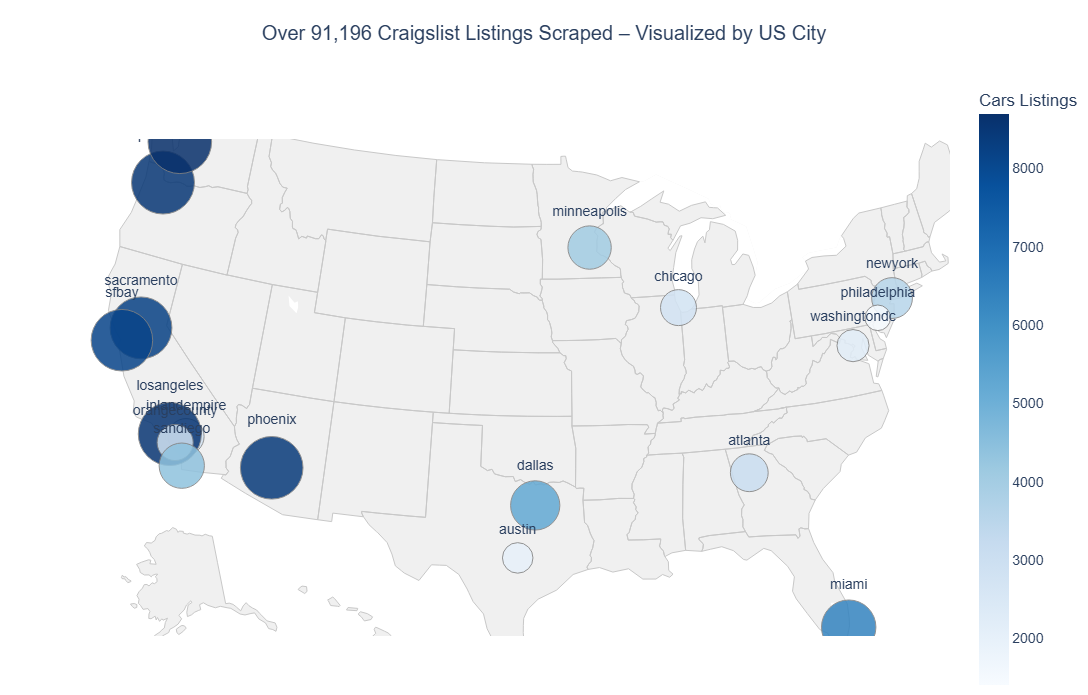

In [35]:
import plotly.express as px

coordinates = {
    'atlanta': (33.7490, -84.3880),
    'austin': (30.2672, -97.7431),
    'chicago': (41.8781, -87.6298),
    'dallas': (32.7767, -96.7970),
    'inlandempire': (34.1083, -117.2898),
    'losangeles': (34.0522, -118.2437),
    'miami': (25.7617, -80.1918),
    'minneapolis': (44.9778, -93.2650),
    'newyork': (40.7128, -74.0060),
    'orangecounty': (33.7175, -117.8311),
    'philadelphia': (39.9526, -75.1652),
    'phoenix': (33.4484, -112.0740),
    'portland': (45.5051, -122.6750),
    'sacramento': (38.5816, -121.4944),
    'sandiego': (32.7157, -117.1611),
    'seattle': (47.6062, -122.3321),
    'sfbay': (37.7749, -122.4194),
    'washingtondc': (38.9072, -77.0369)
}

df_map = df.groupby('region').size().reset_index()
df_map.columns = ['region', 'listings']
df_map['lat'] = df_map['region'].map(lambda r: coordinates[r][0])
df_map['lon'] = df_map['region'].map(lambda r: coordinates[r][1])
total_listings = df_map['listings'].sum()

fig = px.scatter_geo(
    df_map,
    lat='lat',
    lon='lon',
    text='region',
    size='listings',
    color='listings',
    color_continuous_scale='Blues',
    size_max=45,
    scope='usa',
    projection='albers usa',
    title=f"Over {total_listings:,} Craigslist Listings Scraped – Visualized by US City",
    template='plotly_white'
)

fig.update_traces(
    textposition='top center',
    marker=dict(opacity=0.85, line=dict(width=1, color='gray'))
)

fig.update_layout(
    width=1100,
    height=680,
    geo=dict(
        showland=True,
        landcolor="rgb(240,240,240)",
        lakecolor="white",
        subunitcolor="rgb(200,200,200)",
        showlakes=True
    ),
    coloraxis_colorbar=dict(title="Cars Listings"),
    margin=dict(l=0, r=0, t=80, b=0),
    font=dict(family="Arial", size=14),
    title_x=0.5
)

fig.show()
